# Optimization in PyTorch — Gradient Descent, SGD, Numerical Stability, and L1 Regularization

**General guidelines for this (and future) hometasks**

* **Do not delete the task formulations**
* Many hometasks will be like "implement something, then perform experiments, then write your conclusions". We're sure many of you will delegate the first and the second step to coding agents, but please do at least the final stage yourself :)
* The plots should be meaningful: a plot must have a name, every curve or point cloud on a plot must be labeled
* Plots supporting comparison should actually enable it. For example, if you compare training loss curves of two models, they should be either on the same plot or side by side, with the same axis scales
* It goes without saying that the takeaways should actually follow from the evidence ;)

**Learning goals of this hometask**

By completing this assignment, you will:
1. Understand preprocessing design choices (tokenization provided, fixed vocabulary).
2. Implement and train Logistic Regression manually in PyTorch using SGD.
3. Explain why numerical stability matters in softmax and log-loss.
4. Understand how optimization parameters like learning rate and batch size affect training.
5. Understand the effect of L1 regularization and why it encourages sparsity.
6. Understanding how an optimization algorithm behaves when the loss function has different shapes.


**The dataset and the task**

For this assignment, we will use the SST-2 dataset (  [The Stanford Sentiment Treebank](https://huggingface.co/datasets/stanfordnlp/sst2).), a binary sentiment classification dataset in which each sentence is labeled as either negative or positive.

We will use linear models for classification, which means that we need a fixed number of numerical features to describe each sentence. For that, we'll perform:

* **Preprocessing** - to make the data a little more well-behaved
* **Tokenization** - splitting the sentences into atomic units - in this case, words
* **Feature creation** - turning bags of words into numerical features - word frequencies. We keep only 10,000 most frequent words, because we can only work with fixed-length feature vectors. You'll see that more "serious" models, such as LLMs, use fixed-length vocabularies too, though we'll learn how to do it without discarding information (by using sub-word and bit-wise tokenization).

Tokenization and preprocessing are already implemented for you in this task, but we want you to understand understand the design choices behind the them, so please check the description below (in the hidden cells).

### Loading and preparing the dataset

We will perform minimal text cleaning:

   * convert all text to lowercase

   * keep letters, numbers, spaces, and basic punctuation

   * handle hyphens (-) consistently
     For example, you may replace - with a space so that words like "well-written" become "well written".


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets

In [ ]:
from datasets import load_dataset
sst2 = load_dataset("SetFit/sst2")

data_train = sst2['train']
data_val = sst2['validation']

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/378 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

dev.jsonl:   0%|          | 0.00/136k [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/281k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/6920 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

**Text Cleaning**

Before converting text into a numerical representation (e.g., Bag-of-Words), it is important to apply text cleaning.

The goal of this step is to reduce noise and ensure that similar pieces of text are represented consistently.

We use the following cleaning function:

In [ ]:
import re

def clean_text(text:str) -> str:
  #lowercase letters only
  text = text.lower()

  #replace hyphens with space
  text = text.replace('-',' ')

  #keep letters,numbers, spaces, and basic punctuations
  text = re.sub(r'[^a-zA-Z0-9\s.,!?]', '', text)

  #collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()

  return text

#apply cleaning
data_train = data_train.map(lambda x: {'clean_text': clean_text(x['text'])})
data_val = data_val.map(lambda x: {'clean_text': clean_text(x['text'])})



Map:   0%|          | 0/6920 [00:00<?, ? examples/s]

Map:   0%|          | 0/872 [00:00<?, ? examples/s]

In [ ]:
from collections import Counter
import random

random.seed(42)

print(f'size of training set: {len(data_train)}')
print(f'size of validation set: {len(data_val)}\n')

for i in range(5):
  r = random.randint(0,len(data_train))
  print(f'{data_train[r]['label_text']} Text: {data_train[r]['clean_text']} ')


train_counts = Counter(data_train["label"])
val_counts = Counter(data_val["label"])

train_total = len(data_train)
val_total = len(data_val)

print("\nTraining set label distribution:")
print(f"Negative (0): {train_counts[0]} ({train_counts[0] / train_total:.2%})")
print(f"Positive (1): {train_counts[1]} ({train_counts[1] / train_total:.2%})")

print("\nValidation set label distribution:")
print(f"Negative (0): {val_counts[0]} ({val_counts[0] / val_total:.2%})")
print(f"Positive (1): {val_counts[1]} ({val_counts[1] / val_total:.2%})")

size of training set: 6920
size of validation set: 872

positive Text: the extent to which it succeeds is impressive . 
positive Text: remarkable for its excellent storytelling , its economical , compressed characterisations and for its profound humanity , it s an adventure story and history lesson all in one . 
positive Text: the unexpected thing is that its dying , in this shower of black and white psychedelia , is quite beautiful . 
negative Text: matrix style massacres erupt throughout ... but the movie has a tougher time balancing its violence with kafka inspired philosophy . 
positive Text: the closest thing to the experience of space travel 

Training set label distribution:
Negative (0): 3310 (47.83%)
Positive (1): 3610 (52.17%)

Validation set label distribution:
Negative (0): 428 (49.08%)
Positive (1): 444 (50.92%)


We convert the text into numerical vectors that can be used as input for machine learning models.

1. Implementing the Bag-of-Words (BoW) representation building a vocabulary using only the training set.

2. Count the frequency of each token across the training corpus.

3. Keep only the top V=10,000 most frequent tokens (or fewer if memory is limited).

4. Convert each sentence into a sparse vector of token counts.

Each vector should represent how many times each vocabulary word appears in the sentence.

For example, if the vocabulary contains: ["movie", "good", "bad"]

Then the sentence: "good movie good"

Should become: [1,2,0]

**Note:** this is a simple bag of word implementation and not standart practice.


In [ ]:
def tokenize(text):
  '''Helper function to split the text into words/tokens'''
  return text.split()

def build_vocabulary(data, top_k=10000):
  '''Build a vocabulary from the training data.'''
  token_counter = Counter()
  for text in data['clean_text']:
    tokens = tokenize(text)
    token_counter.update(tokens)
  most_common = token_counter.most_common(top_k)
  vocab = {word: i for i, (word, _) in enumerate(most_common)}
  return vocab

def convert_text_to_vec(text, vocab):
  '''Convert text into a vector of token counts.'''
  tokens = tokenize(text)
  vec = np.zeros(len(vocab), dtype=int)
  for token in tokens:
    if token in vocab:
      vec[vocab[token]] += 1
  return vec

def dataset_to_vec(data,vocab) :
  '''Convert the dataset into a vector of token counts.'''
  vectors = []
  for text in data['clean_text']:
    vec = convert_text_to_vec(text, vocab)
    vectors.append(vec)
  return np.array(vectors)


In [ ]:
import numpy as np

# Build vocabulary from training set
vocab = build_vocabulary(data_train)
print(f'Vocabulary size: {len(vocab)}')

# Vectorize training data
train_vectors = dataset_to_vec(data_train, vocab)
print(f'Vectorized training data shape: {train_vectors.shape}')

# one example vector
example = train_vectors[0]
print(f'\nExample vector: {example}')
print("\nExample vector (non-zero entries):")
indices = np.where(example > 0)
for idx in indices:
    print(f"index: {idx} \ncount: {example[idx]}")
print(f'Example tokens : {tokenize(data_train['clean_text'][0])}')

print(f'Length of tokens: {len(tokenize(data_train['clean_text'][0]))}')
print(f'Length of non-zero entries: {len(indices[0])}')

Vocabulary size: 10000
Vectorized training data shape: (6920, 10000)

Example vector: [0 1 1 ... 0 0 0]

Example vector (non-zero entries):
index: [   1    2    3    4    5   66  118  119  361  554  646 1317 1822 4926
 7197 7198] 
count: [1 1 1 3 1 1 1 1 1 1 1 1 1 1 1 1]
Example tokens : ['a', 'stirring', ',', 'funny', 'and', 'finally', 'transporting', 're', 'imagining', 'of', 'beauty', 'and', 'the', 'beast', 'and', '1930s', 'horror', 'films']
Length of tokens: 18
Length of non-zero entries: 16


**Our training data for the task 1 will be:**

In [ ]:
X_train = train_vectors
y_train = np.array(data_train["label"], dtype=np.float32)
X_val = dataset_to_vec(data_val, vocab)
y_val =  np.array(data_val["label"], dtype=np.float32)


### **Part 1 - Implement SGD for Logistic Regression in PyTorch (70 points)**

#### **Task 1.1 - Binary vs. Softmax Formulation and Numerical Stability of Cross-Entropy Loss (10 points)**



In this task, you will explore two ways to formulate the loss function for a classification problem and understand why numerical stability is important.

**a. Binary formulation**

   In the binary formulation, the model has:

   * a single output
   * sigmoid activation
   * binary cross-entropy loss

   This produces a probability: P(y=1|x)
   
   A prediction is then obtained using a threshold:
   * predict class 1 if p>0.5
   * otherwise predict class 0

   For binary logistic regression, the standard loss function is the **binary cross-entropy loss**:

   $L= -\frac{1}{N}\sum_{i=1}^N[y_ilog(\hat{y_i})+(1-y_i)log(1-\hat{y_i})]$

   where $\hat{y_i}$ is the predicted probability after applying sigmoid.

   Since this loss contains both: $log(\hat{y})$ and $log(1-\hat{y})$ , numerical problems may appear if $\hat{y_i}$ becomes extremely close to 0 or 1.

   A stable implementation should therefore clamp the predicted probabilities:
```
y_pred = # SIGMOID(LOGITS)
epsilon = 1e-15  
y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
log_loss = # <SMTH FROM y_pred>
```

**Note:** the threshold 0.5 is used only to convert probabilities into class predictions for evaluation.
It must not be used inside the loss function.

**b. Softmax formulation**

  Now, we will reformulate the same problem as a 2-class classification problem using softmax (This formulation is more general and can also be used for more than 2 classes.).
  
  **Step 1 — Convert labels to one-hot encoding**
  
  In our dataset the labels are either 1 or 0 (i.e positive or negetive). To use softmax will require us to convert the labels into a one-hot representation:
  * class 0 ---> [1,0]
  * class 1 ---> [0,1]

  Now our model will output 2 outputs instead of 1 and we will require to apply softmax to get the probability of class 0 vs. class 1.

  **Step 2 - Implementing softmax and log-loss**
  
   This can be implemented in two ways:

  1. **Naive version:**
  
     Given logits z = [$z_1,z_2,...,z_k$]

     softmax($z_i$) = $\frac{\exp(z_i)}{\sum_j\exp(z_j)}$


  2. **Stable version:**

     softmax($z_i$) = $\frac{\exp(z_i-max(z))}{\sum_j\exp(z_j-max(z))}$

   Than the cross entropy loss for the true class y is :

   **L = -log(softmax($z_y$))**

   or equivalently, for one-hot labels:
   
   **$L= -\sum_{c=1}^Ky_clog(\hat{y_c})$**

**Task**

A. Conceptual questions

For both the binary and softmax formulations, explain:

* Why do we need numerical stability? Where can the naive implementation fail?
* Why does the stability transformation not change the final softmax probabilities?
* Why does this transformation improve numerical stability?

B. Implementation
1. Implement a binary cross-entropy loss function for the binary formulation.
2. Make sure your implementation is numerically stable.




### Task 1.1 — Conceptual Questions

**A. Why do we need numerical stability? Where can the naive implementation fail?**

**Binary formulation:**
The naive BCE loss computes log(y_pred) and log(1 - y_pred) directly. If the sigmoid output is extremely close to 0 or 1 (which happens when the logit is very large positive or negative), we get log(0) = -inf, which produces NaN in the loss and kills training. The fix is to clamp y_pred to [1e-15, 1 - 1e-15], keeping the log arguments in a safe range.

**Softmax formulation:**
The naive softmax computes exp(z_i) / sum(exp(z_j)). If any logit z_i is large (e.g. 1000), exp(1000) overflows to inf in float32. Then inf / inf = NaN. Even moderately large logits like 90 overflow in float32, since the maximum representable value is ~3.4×10³⁸ and exp(90) ≈ 1.2×10³⁹.

---

**B. Why does the stability transformation NOT change the softmax output?**

The stable version subtracts max(z) from all logits before exponentiating:

$$\text{softmax}(z_i) = \frac{e^{z_i - \max(z)}}{\sum_j e^{z_j - \max(z)}}$$

This is mathematically identical to the original because the constant cancels:

$$\frac{e^{z_i - c}}{\sum_j e^{z_j - c}} = \frac{e^{z_i} \cdot e^{-c}}{\sum_j e^{z_j} \cdot e^{-c}} = \frac{e^{z_i}}{\sum_j e^{z_j}}$$

The constant c = max(z) appears in both numerator and denominator and cancels exactly. The transformation is a purely numerical trick, not an approximation.

---

**C. Why does the transformation improve numerical stability?**

After subtracting max(z), all shifted logits z_i - max(z) are <= 0. The largest value is exactly 0, so exp(0) = 1 is the largest exponent computed. All others are in (0, 1], which are safely representable in float32. Overflow is impossible. The denominator is at least 1 (from the max term), so division by zero is also prevented.

In [ ]:
def binary_cross_entropy_loss(y_pred, y_true):
    """
    Compute the binary cross-entropy loss for a logistic regression model.
    """
    epsilon = 1e-15
    # clamp y_pred for numerical stability
    y_pred  = torch.clamp(y_pred, epsilon, 1.0 - epsilon)

    # Compute binary log-loss remmber that the loss should provide a scalar value for the backwards to work
    loss = -(y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
    loss = loss.mean()
    return loss

####**Task 1.2. - Implement Logistic Regression in PyTorch (10 points)**



In this task, you will implement a logistic regression model from scratch using PyTorch primitives.

The logistic regression prediction function is:

$\hat{Y} = \frac{1}{1+exp^{-(wx +b)}}$

Complete the class below.

You are required to implement:

1. weight initialization (with different options)
2. the forward pass (logits + sigmoid)
3. prediction logic (thresholding)

In [ ]:
import torch
import torch.nn as nn

class LogisticRegression(nn.Module):

    def __init__(self, n_features, init="zeros"):
        """
        Parameters
        ----------
        n_features : int
            Number of input features

        init : str or torch.Tensor
            Initialization method for weights:
            - "zeros"  -> initialize weights to zeros
            - "random" -> small random values (recommended scale ~0.01)
            - torch.Tensor -> use provided tensor
        """

        super().__init__()

        # TODO:
        # Initialize the weight vector `w` based on the `init` argument
        # Make sure:
        # - shape is (n_features, 1)
        # - random initialization uses SMALL values (important!)
        # - if init is a tensor, clone + detach it

        if init == "zeros":
            w = torch.zeros(n_features, 1)

        elif init == "random":
            w = torch.randn(n_features, 1) * 0.01

        elif isinstance(init, torch.Tensor):
            w = init.clone().detach().float().view(n_features, 1)

        else:
            raise ValueError("init must be 'zeros', 'random', or a torch.Tensor")

        # TODO:
        # Wrap weights and bias using nn.Parameter
        self.w = nn.Parameter(w)
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """
        Forward pass

        Steps:
        1. Compute logits: x @ w + b
        2. Apply sigmoid to get probabilities

        Returns
        -------
        probs : torch.Tensor
            Values in range [0, 1]
        """

        # TODO:
        logits = x @ self.w + self.b
        probs = torch.sigmoid(logits)

        return probs

    def predict(self, x):
        """
        Convert probabilities to class predictions

        Rule:
        - class 1 if p >= 0.5
        - class 0 otherwise
        """

        # TODO:
        probs = probs = self.forward(x)
        preds = (probs >= 0.5).float()

        return preds

####**Task 1.3 - Train Logistic Regression with SGD Using Your Previous Implementations (10 point)**



In this task, you will train the logistic regression model you implemented earlier using mini-batch stochastic gradient descent (SGD).

You must use:

1. your LogisticRegression class from Task 1.2
2. your binary_cross_entropy_loss function from Task 1.1

The goal of this task is to practice building a full training loop in PyTorch while keeping the model and loss implementations modular.

Your function should
1. Initialize a LogisticRegression model
2. Train it on the training set using mini-batch SGD
3. Record the training log-loss after each epoch
4. Compute and report evaluation metrics on both the training and validation sets after each epoch.
You may choose any evaluation metric you find appropriate, such as accuracy, precision, recall, or F1-score, but you must briefly explain why this metric is suitable for this task.
5. Save the model parameters w and b after each batch update into a history log
6. Return:
   * the final trained parameters w and b
   * the batch-wise history of w and b


Bellow is a suggested skeleton you may revised



In [ ]:
import torch
from sklearn.metrics import f1_score, accuracy_score

def sgd_logistic_regression(
    X_train, y_train,
    X_val, y_val,
    lr=0.01,
    epochs=20,
    batch_size=100,
    init="zeros",
    penalty='none',          # For Task 1.5 : options: 'none', 'l1', 'l2'
    reg_lambda=0.0,          # For Task 1.5
    metric='accuracy',
    print_metrics=False
):
    """
    Train a logistic regression model using mini-batch SGD.

    You must use:
    - LogisticRegression
    - binary_cross_entropy_loss

    Parameters
    ----------
    X_train, y_train : training data
    X_val, y_val     : validation data
    lr : float
        Learning rate
    epochs : int
        Number of passes over the training data
    batch_size : int
        Mini-batch size
    init : str
        Weight initialization passed to LogisticRegression
    penalty : str
        'none', 'l1', or 'l2'
    reg_lambda : float
        Regularization strength
    metric : str
        Evaluation metric to report ('accuracy' , 'f1' or other)
    print_metrics : bool
        Whether to print metrics after each epoch

    Returns
    -------
    w : numpy.ndarray
        Final learned weights
    b : numpy.ndarray
        Final learned bias
    history : list
        Batch-wise history of parameter values
    epoch_log : list
        Per-epoch logs (loss + metrics)
    """


    # 1. Convert data to tensors

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

    n_samples, n_features = X_train_tensor.shape


    # 2. Initialize model

    model = LogisticRegression(n_features=n_features, init=init)


    # 3. Create optimizer

    optimizer = torch.optim.SGD(model.parameters(), lr=lr)


    # 4. Create logs

    history = []      # save w, b after each batch update
    epoch_log = []    # save epoch-level loss and metrics


    # 5. Training loop

    for epoch in range(epochs):

        # TODO:
        # Shuffle the training data at the beginning of each epoch
        perm = torch.randperm(n_samples)
        X_train_epoch = X_train_tensor[perm]
        y_train_epoch = y_train_tensor[perm]


        for start in range(0, n_samples, batch_size):

            end = start + batch_size

            # TODO:
            # Select mini-batch
            X_batch = X_train_epoch[start:end]
            y_batch = y_train_epoch[start:end]

            # TODO:
            # Forward pass
            y_pred = model(X_batch)

            # TODO:
            # Compute non-regularized BCE loss using your function
            data_loss = binary_cross_entropy_loss(y_pred, y_batch)

            # TODO in task 1.5:
            # Add regularization if needed
            # penalty == 'l1'  -> reg_lambda * ||w||_1
            # penalty == 'l2'  -> reg_lambda * ||w||_2^2
            # penalty == 'none' -> no regularization
            if penalty == 'l1':
                reg_term = reg_lambda * model.w.abs().sum()
            elif penalty == 'l2':
                reg_term = reg_lambda * (model.w ** 2).sum()
            else:
                reg_term = 0.0

            loss = data_loss + reg_term

            # TODO:
            # Backward pass and optimization step

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # TODO:
            # Save current parameter values after the batch update
            history.append({
                'epoch': epoch,
                'batch_start': start,
                'w': model.w.detach().clone(),
                'b': model.b.detach().clone()
            })


        # 6. Epoch-level evaluation

        with torch.no_grad():

            # TODO:
            # Compute probabilities on full train/val sets
            y_pred_train = model(X_train_tensor)
            y_pred_val = model(X_val_tensor)


            # TODO:
            # Compute NON-regularized train loss and val loss
            train_loss = binary_cross_entropy_loss(y_pred_train, y_train_tensor)
            val_loss = binary_cross_entropy_loss(y_pred_val,   y_val_tensor)

            # TODO:
            # Convert probabilities to binary predictions
            y_hat_train = model.predict(X_train_tensor).numpy().flatten()
            y_hat_val = model.predict(X_val_tensor).numpy().flatten()

            # TODO:
            # Compute evaluation metric
            if metric == 'f1':
                train_metric = f1_score(y_train, y_hat_train, zero_division=0)
                val_metric   = f1_score(y_val,   y_hat_val,   zero_division=0)

            else:
                train_metric = accuracy_score(y_train, y_hat_train)
                val_metric = accuracy_score(y_val,   y_hat_val)

        epoch_log.append({
            'epoch': epoch,
            'train_loss': train_loss.item(),
            'val_loss': val_loss.item(),
            'train_metric': train_metric,
            'val_metric': val_metric
        })

        if print_metrics:
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Train Loss: {train_loss.item():.4f} | "
                f"Val Loss: {val_loss.item():.4f} | "
                f"Train {metric}: {train_metric:.4f} | "
                f"Val {metric}: {val_metric:.4f}"
            )

    return model.w.detach().numpy(), model.b.detach().numpy(), history, epoch_log

####**Task 1.4 - Experiments (20 points)**




Run multiple experiments with different combinations of:
* learning rates - [0.01, 0.03, 0.1 , 0.3 , 1.0]
* batch sizes - [50, 100 , 200]

For each experiment, record the final train and validation evaluation metric and the log-loss.

**Visualization:**

Present your results using a heatmap, where:
* X-axis: learning rate
* Y-axis: batch size
* Values: evaluation metric (train / validation)


**Analysis:**

Explain (in text) how learning rate and batch size affect:
- convergence speed
- stability of training
- final performance

Support your explanation using the patterns observed in your heatmap.


Metric choice: ACCURACY
SST-2 is nearly balanced (~47 % negative, ~53 % positive), so accuracy
is a fair summary statistic and easy to interpret.

 Accuracy is defined as the fraction of correctly classified samples:
Accuracy = (TP + TN) / (TP + TN + FP + FN)

F1 score would be preferred over accuracy in heavily imbalanced datasets (for example, 95% negative, 5% positive), where a model that always predicts the majority class achieves high accuracy without learning anything useful.

F1 balances precision and recall, penalizing the model for ignoring the minority class:
F1 = 2 * (Precision * Recall) / (Precision + Recall)
Since SST-2 does not suffer from this imbalance problem, accuracy is sufficient and easier to interpret, a value of 0.78 means the model correctly classifies 78 out of every 100 sentences, which is intuitive and directly comparable across experiments.

  lr=0.01  bs=50
  lr=0.03  bs=50
  lr=0.1  bs=50
  lr=0.3  bs=50
  lr=1.0  bs=50
  lr=0.01  bs=100
  lr=0.03  bs=100
  lr=0.1  bs=100
  lr=0.3  bs=100
  lr=1.0  bs=100
  lr=0.01  bs=200
  lr=0.03  bs=200
  lr=0.1  bs=200
  lr=0.3  bs=200
  lr=1.0  bs=200


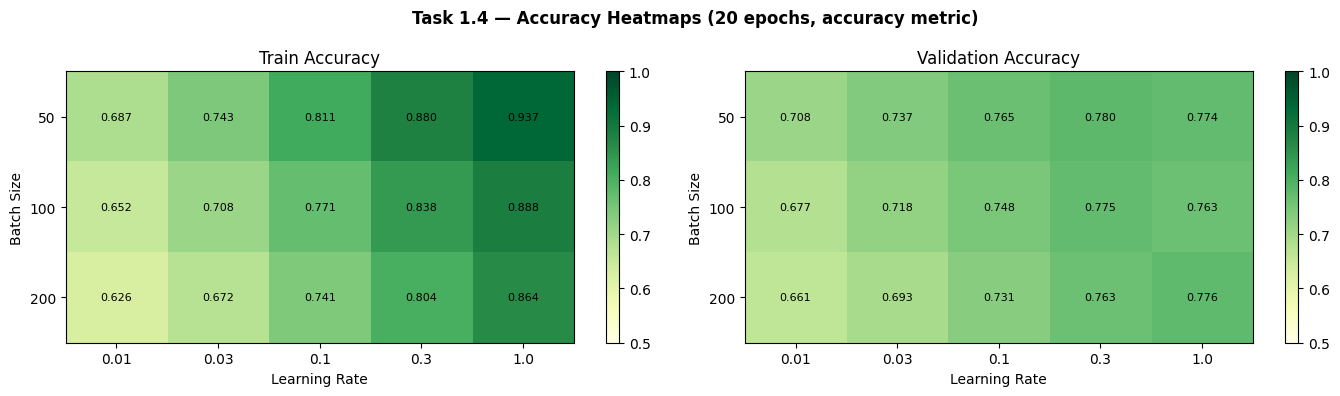

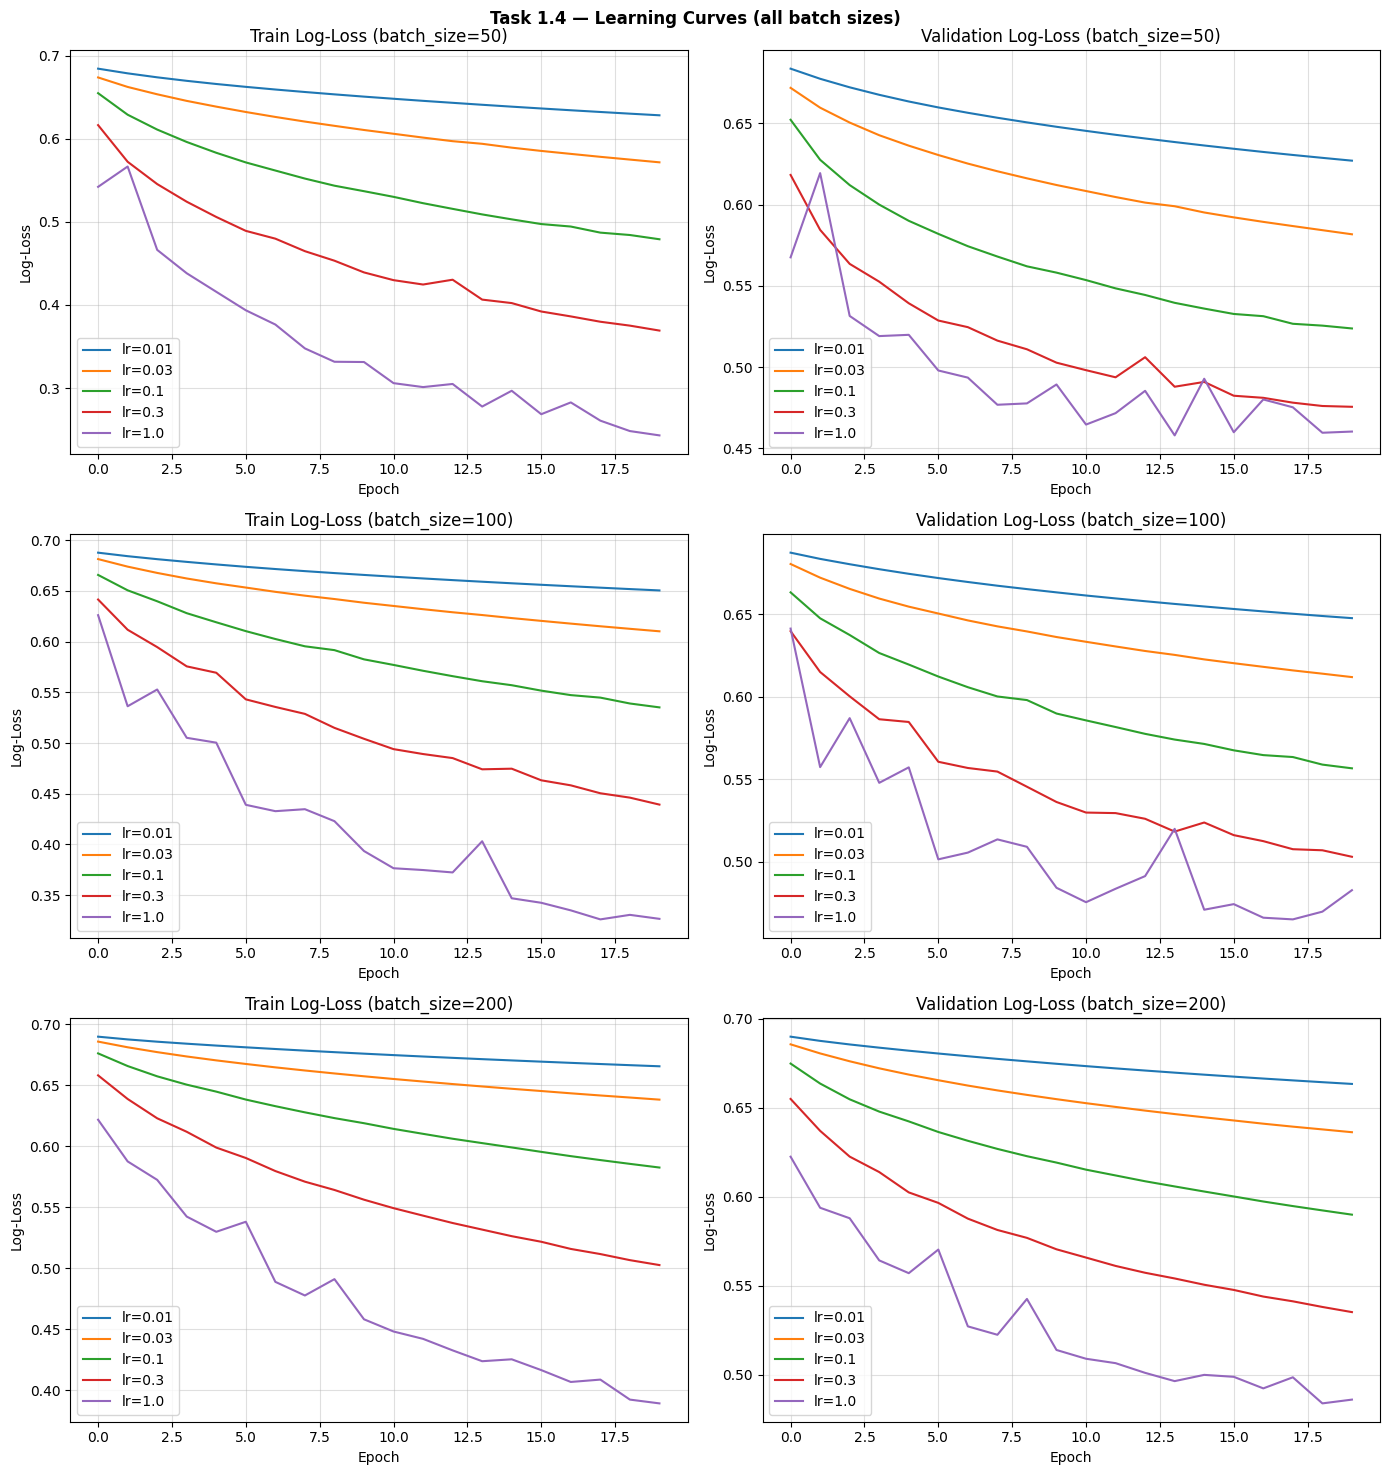

In [ ]:
import matplotlib.pyplot as plt

"""
Metric choice: ACCURACY
SST-2 is nearly balanced (~47 % negative, ~53 % positive), so accuracy
is a fair summary statistic and easy to interpret.  F1 would be preferred
for heavily imbalanced datasets.
"""

lrs         = [0.01, 0.03, 0.1, 0.3, 1.0]
batch_sizes = [50, 100, 200]

results = {}      # (lr, bs) -> (train_acc, val_acc, train_loss, val_loss)
elogs   = {}      # (lr, bs) -> epoch log (for learning curves)

for bs in batch_sizes:
    for lr in lrs:
        print(f"  lr={lr}  bs={bs}")
        _, _, _, elog = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=lr, epochs=20, batch_size=bs
        )
        last = elog[-1]
        results[(lr, bs)] = (last['train_metric'], last['val_metric'],
                             last['train_loss'],   last['val_loss'])
        elogs[(lr, bs)] = elog

#  Accuracy Heatmaps
train_acc_grid = np.array([[results[(lr, bs)][0] for lr in lrs] for bs in batch_sizes])
val_acc_grid   = np.array([[results[(lr, bs)][1] for lr in lrs] for bs in batch_sizes])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, data, title in zip(
        axes,
        [train_acc_grid, val_acc_grid],
        ["Train Accuracy", "Validation Accuracy"]):
    im = ax.imshow(data, aspect='auto', vmin=0.5, vmax=1.0, cmap='YlGn')
    ax.set_xticks(range(len(lrs)));        ax.set_xticklabels(lrs)
    ax.set_yticks(range(len(batch_sizes))); ax.set_yticklabels(batch_sizes)
    ax.set_xlabel("Learning Rate");        ax.set_ylabel("Batch Size")
    ax.set_title(title)
    for i in range(len(batch_sizes)):
        for j in range(len(lrs)):
            ax.text(j, i, f"{data[i,j]:.3f}", ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax)

plt.suptitle("Task 1.4 — Accuracy Heatmaps (20 epochs, accuracy metric)", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nebius_Course/task14_heatmaps.png', dpi=120)
plt.show()

# Learning Curves
fig, axes = plt.subplots(len(batch_sizes), 2, figsize=(14, 5 * len(batch_sizes)))

for row, bs in enumerate(batch_sizes):
    for lr in lrs:
        train_losses = [e['train_loss'] for e in elogs[(lr, bs)]]
        val_losses   = [e['val_loss']   for e in elogs[(lr, bs)]]
        axes[row, 0].plot(train_losses, label=f"lr={lr}")
        axes[row, 1].plot(val_losses,   label=f"lr={lr}")

    for ax, title in zip(axes[row], ["Train Log-Loss", "Validation Log-Loss"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Log-Loss")
        ax.set_title(f"{title} (batch_size={bs})")
        ax.legend()
        ax.grid(True, alpha=0.4)

plt.suptitle("Task 1.4 — Learning Curves (all batch sizes)", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nebius_Course/task14_curves.png', dpi=120)
plt.show()


**Convergence Speed**

The learning curves show a clear pattern across all batch sizes: higher learning rates converge much faster. lr=1.0 and lr=0.3 drop steeply in the first 2-5 epochs, while lr=0.01 barely moves across all 20 epochs regardless of batch size. Batch size also affects speed. Comparing rows, bs=50 (row 1) converges faster than bs=200 (row 3) at the same learning rate, because smaller batches perform more gradient updates per epoch.

**Stability of Training**

The oscillation problem at lr=1.0 is clearly visible and worsens with smaller batch sizes. At bs=50, the validation curve for lr=1.0 shows sharp spikes up to epoch 15. At bs=100 the spikes are smaller, and at bs=200 the curve is noticeably smoother. Larger batches produce more reliable gradient estimates, which dampens oscillations. lr=0.3 shows mild oscillation only at bs=50, and is smooth for bs=100 and bs=200.

**Overfitting**

The clearest sign of overfitting appears at lr=1.0, bs=100, where after around epoch 13 the validation loss starts rising while the training loss continues to decrease. This is the classic overfitting signature. At bs=50 with lr=1.0 the validation curve oscillates heavily, making it harder to identify a clean overfitting point, and at bs=200 the curves remain more stable. For lower learning rates (lr=0.3 and below) no overfitting is observed within 20 epochs, as both train and validation loss decrease together throughout.

**What is probably the best option**

The best validation accuracy overall is 0.780 (lr=0.3, bs=50) and 0.775-0.776 (lr=0.3, bs=100 and lr=1.0, bs=200). lr=0.3 with bs=100 offers the best overall balance: strong validation accuracy (0.775), smooth convergence, and a modest train/val gap of only 0.063. However, if training were extended beyond 20 epochs, a lower learning rate such as lr=0.1 would likely be preferable. The learning curves show it is still steadily descending without any oscillation, suggesting it has not yet converged and would continue to improve stably over more epochs, whereas lr=1.0 and lr=0.3 already show signs of plateauing or oscillating on the validation set.

####**Task 1.5 — L1 Regularization and Sparsity (20 points)**



In this task, you will extend your implementation from Task 1.2 (SGD training) to include **L1 regularization**, and study how it affects the model.

**What is Regularization/ Penalty**

When there are too many features, some features might not be so important at all, but if we keep it, and try to fit our model to it perfectly, then it might overfit, trying to capture noisy (irrelevant) data or patterns. To reduce this overfitting so the model generalizes well and remove noisy data we use **regularization**. In linear models, mostly these regularization techniques are used:

* **L1 Penalty**: adding $\lambda *\sum{|w_i|}$ to the loss function

* **L2 Penalty**: adding $\lambda *\sum{||w||_i^2}$ to the loss function


**Why is this important?**

L1 *sparsifies* data, with part of weights being pushed strongly towards zero (with the right optimization technique, these weights become almost zero).
This leads to implicit feature selection.

In contrast, L2 shrinks weights but rarely makes them exactly zero.

**Task**

1. Modify your `sgd_logistic_regression` function from Task 1 to include L1 penalty.

2. Compare weight initialization:
   
   Try initializing the weight vector w in two different ways:
   * All zeros
   * Small random values
   
   Compare:
    * Stability (does training diverge? NaNs?)
    * Final performance
    * Sparsity (how many weights go to zero, use a small tolerance like 1e-7). Note that you'll unlikely get zeros. You'd need special optimization methods such as *proximal descent* to get true feature elimination; with SGD you'll still make part of the weights really small, so you'll still observe the pattern.
   
3. Study the effect of $\lambda$
   
   Run experiments with:

          reg_lambda = [0,1e-4,1e-3,1e-2,1e-1]
    
     Keep other parameters fixed (recommended):
     
      *  lr = 0.1
      *  batch_size = 100
     
     For each λ, record:
      * Train metric (for example accuracy or F1)
      * Validation metric
      * Number of non-zero weights that exceed a small threshold such as 1e-7

4. Visualization
     
     Plot:
       
     * number of non-zero weights vs lambda
     * train metric vs lambda
     * for a subset of features that get eliminated by the l1 regularization, training dynamics of their weights (weight vs step)

5. Write a small paragraph summarizing your insights

  init=zeros  lambda=0
  init=zeros  lambda=0.0001
  init=zeros  lambda=0.001
  init=zeros  lambda=0.01
  init=zeros  lambda=0.1
  init=random  lambda=0
  init=random  lambda=0.0001
  init=random  lambda=0.001
  init=random  lambda=0.01
  init=random  lambda=0.1


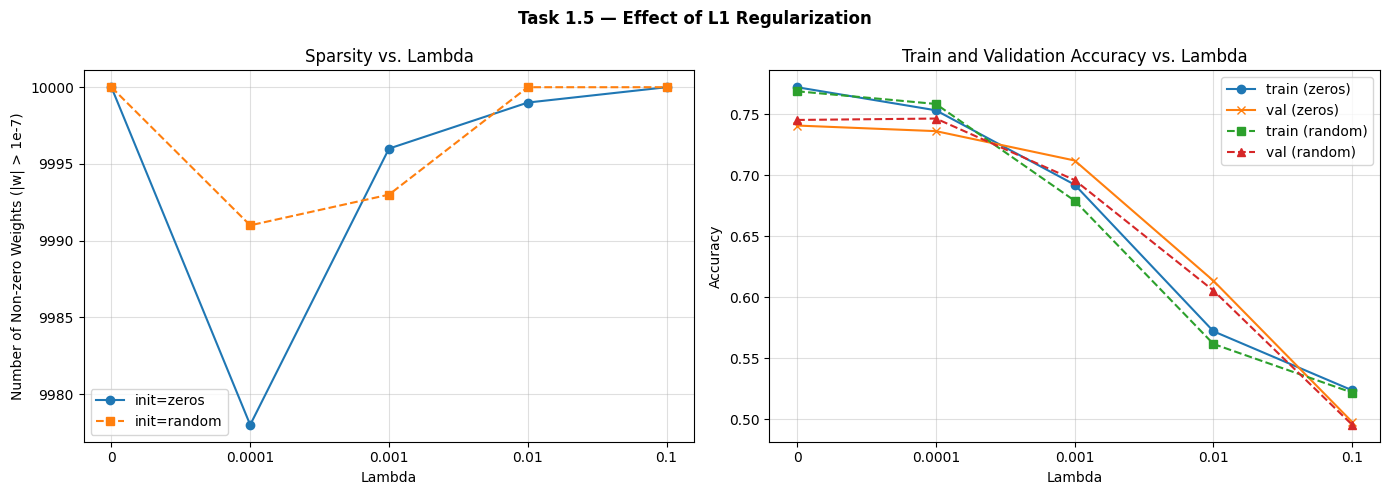

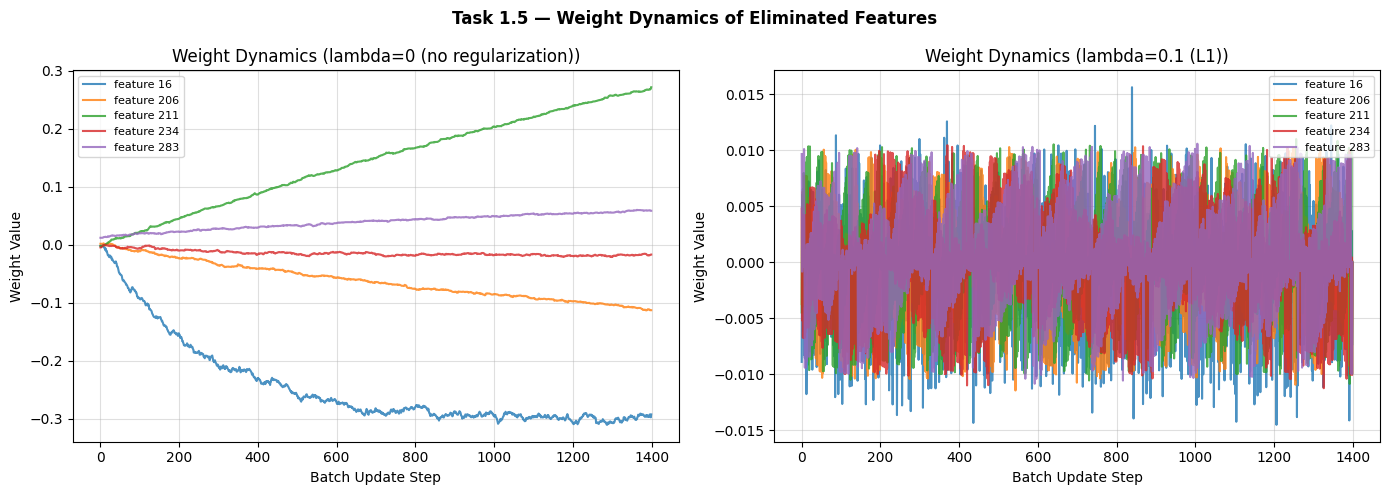


Stability and Performance Summary:
Init       Lambda     Train Acc    Val Acc      Non-zeros    NaN?
-----------------------------------------------------------------
zeros      0          0.7723       0.7408       10000        False
zeros      0.0001     0.7533       0.7362       9978         False
zeros      0.001      0.6923       0.7122       9996         False
zeros      0.01       0.5721       0.6135       9999         False
zeros      0.1        0.5237       0.4977       10000        False
random     0          0.7689       0.7454       10000        False
random     0.0001     0.7585       0.7466       9991         False
random     0.001      0.6792       0.6961       9993         False
random     0.01       0.5617       0.6055       10000        False
random     0.1        0.5218       0.4954       10000        False


In [ ]:
import matplotlib.pyplot as plt

reg_lambdas = [0, 1e-4, 1e-3, 1e-2, 1e-1]
results_l1  = {}

for init_mode in ['zeros', 'random']:
    results_l1[init_mode] = {}
    for lam in reg_lambdas:
        print(f"  init={init_mode}  lambda={lam}")
        w_final, b_final, history_l1, elog_l1 = sgd_logistic_regression(
            X_train, y_train, X_val, y_val,
            lr=0.1, epochs=20, batch_size=100,
            init=init_mode, penalty='l1', reg_lambda=lam
        )
        n_nonzero = int(np.sum(np.abs(w_final) > 1e-7))
        last      = elog_l1[-1]
        has_nan   = bool(np.isnan(w_final).any())
        results_l1[init_mode][lam] = {
            'w':         w_final,
            'history':   history_l1,
            'train_acc': last['train_metric'],
            'val_acc':   last['val_metric'],
            'n_nonzero': n_nonzero,
            'has_nan':   has_nan
        }

#  Plot 1: Sparsity and Accuracy vs lambda
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for init_mode, style in [('zeros', 'o-'), ('random', 's--')]:
    nonzeros   = [results_l1[init_mode][l]['n_nonzero']  for l in reg_lambdas]
    train_accs = [results_l1[init_mode][l]['train_acc']  for l in reg_lambdas]
    val_accs   = [results_l1[init_mode][l]['val_acc']    for l in reg_lambdas]

    axes[0].plot(range(len(reg_lambdas)), nonzeros,   style, label=f"init={init_mode}")
    axes[1].plot(range(len(reg_lambdas)), train_accs, style, label=f"train ({init_mode})")
    axes[1].plot(range(len(reg_lambdas)), val_accs,   style.replace('o','x').replace('s','^'),
                 label=f"val ({init_mode})")

axes[0].set_xticks(range(len(reg_lambdas)))
axes[0].set_xticklabels([str(l) for l in reg_lambdas])
axes[0].set_xlabel("Lambda")
axes[0].set_ylabel("Number of Non-zero Weights (|w| > 1e-7)")
axes[0].set_title("Sparsity vs. Lambda")
axes[0].legend()
axes[0].grid(True, alpha=0.4)

axes[1].set_xticks(range(len(reg_lambdas)))
axes[1].set_xticklabels([str(l) for l in reg_lambdas])
axes[1].set_xlabel("Lambda")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Train and Validation Accuracy vs. Lambda")
axes[1].legend()
axes[1].grid(True, alpha=0.4)

plt.suptitle("Task 1.5 — Effect of L1 Regularization", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nebius_Course/task15_l1_sparsity.png', dpi=120)
plt.show()

# Plot 2: Weight dynamics for features eliminated by L1
lam_high = 1e-1
lam_none = 0

w_high = results_l1['random'][lam_high]['w'].flatten()
w_none = results_l1['random'][lam_none]['w'].flatten()

# Features near-zero under high L1 but active without regularization
eliminated = np.where((np.abs(w_high) < 1e-4) & (np.abs(w_none) > 1e-2))[0][:5]

history_none = results_l1['random'][lam_none]['history']
history_high = results_l1['random'][lam_high]['history']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for feat in eliminated:
    vals_none = [h['w'][feat, 0].item() for h in history_none]
    vals_high = [h['w'][feat, 0].item() for h in history_high]
    axes[0].plot(vals_none, alpha=0.8, label=f"feature {feat}")
    axes[1].plot(vals_high, alpha=0.8, label=f"feature {feat}")

for ax, title in zip(axes, ["lambda=0 (no regularization)", f"lambda={lam_high} (L1)"]):
    ax.set_xlabel("Batch Update Step")
    ax.set_ylabel("Weight Value")
    ax.set_title(f"Weight Dynamics ({title})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.4)

plt.suptitle("Task 1.5 — Weight Dynamics of Eliminated Features", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nebius_Course/task15_weight_dynamics.png', dpi=120)
plt.show()

# Stability summary
print("\nStability and Performance Summary:")
print(f"{'Init':<10} {'Lambda':<10} {'Train Acc':<12} {'Val Acc':<12} {'Non-zeros':<12} {'NaN?'}")
print("-" * 65)
for init_mode in ['zeros', 'random']:
    for lam in reg_lambdas:
        r = results_l1[init_mode][lam]
        print(f"{init_mode:<10} {str(lam):<10} {r['train_acc']:<12.4f} "
              f"{r['val_acc']:<12.4f} {r['n_nonzero']:<12} {r['has_nan']}")

**My Insights** :

**Stability (NaN check)**:

Neither initialization produced NaN values across any lambda value  training was stable throughout. Both zero and random initialization behave similarly in terms of numerical stability, which makes sense since the weights are small in both cases (zeros start at 0, random starts at scale 0.01).

**Sparsity vs. Lambda (left plot)**:

The sparsity plot shows a surprising pattern: the number of non-zero weights dips at lambda=0.0001 (zeros: 9978, random: 9991) and then rises back toward 10000 at higher lambdas. This seems counterintuitive, I expect more sparsity with higher lambda. The explanation is the "leaping around zero" behavior visible in the weight dynamics plot: at very high lambda (0.1), the L1 penalty pushes weights so aggressively that they oscillate around zero with amplitude larger than the 1e-7 threshold, so they are counted as non-zero. True sparsity would require proximal descent as noted in the Knowledge Bonus section.

**Accuracy vs. Lambda (right plot)**:

The accuracy drop is significant and consistent across both initializations:

lambda=0: ~0.77 train, ~0.74 val (best performance)
lambda=0.0001: nearly unchanged, safe to use
lambda=0.001: noticeable drop to ~0.69 train, ~0.71 val
lambda=0.01: significant degradation to ~0.57 train, ~0.61 val
lambda=0.1: model collapses near ~0.52, barely above random chance

Both initializations perform almost identically at every lambda level, confirming that initialization choice does not significantly affect final performance here.

**Weight Dynamics (right plot)**:

The weight dynamics plot perfectly illustrates the theoretical prediction from the Knowledge Bonus. Without regularization (left), the selected features develop meaningful, stable weights feature 211 grows to +0.28, feature 16 drops to -0.30, showing these are genuinely informative features. With lambda=0.1 (right), all the same features are confined to a tiny range of roughly [-0.015, +0.015] and oscillate continuously around zero, this is exactly the "leaping around zero with force ±alpha*lambda" behavior described in the Knowledge Bonus, confirming that SGD cannot achieve true zero weights without proximal descent.

**Conclusion** :

Lambda=0.0001 is the practical sweet spot, it introduces mild sparsity with virtually no accuracy cost. Beyond lambda=0.001 the regularization becomes too aggressive for this dataset, suppressing genuinely useful features and hurting performance significantly.

### **Part 2 - Comparing Optimization Algorithms on a Simple vs. Difficult Function (30 points)**


In this task, you will implement and compare several optimization algorithms on two different mathematical functions.

An optimization algorithm is a method used to update the model's parameters (weights and bias) in order to minimize the loss function.

At each step, it uses the gradients (how the loss changes) to decide:
- in which direction to move
- and how big the update should be

Different optimizers (like SGD, Adam) differ in how they use the gradients and how they control the step size, which affects how fast and how stably the model learns.

The purpose of this task is to help you build intuition for how optimization behaves in:

1. a simple convex function

2. a function with a narrow curved valley

You will implement the following optimizers:

* Gradient Descent (GD)
* Momentum
* AdaGrad
* Adam

Use your optimizers on the following functions:

Function A — Convex bowl:

$f(x,y)= x^2 +4y^2$

This is a simple convex function with a single global minimum.

Function B — the Six-hump Camel function:

$$
\left(4-2.1x^2+\frac{x^4}{3}\right)x^2+xy+\left(-4+4y^2\right)y^2.
$$

This function is much harder to optimize. It has two global minima: $(0.0898, -0.7126)$ and $(-0.0898,0.7126)$, with value about $-1.0316$ - and also several local minina.

Start from at least one non-optimal initial point, for example: (-2, -1.5)


**Task**

For each optimizer and for each function:

1. Initialize the parameters (x,y)
2. repeatedly compute the gradient
3. Update the parameters according to the optimizer rule
4. Record:
  * the function value at each iteration
  * the parameter values $(x_t,y_t)$ at each iteration

**Goal**

Compare how the different optimizers behave on:

* a simple convex function
* a difficult non-convex function

In particular, observe:

* how quickly each optimizer converges
* whether the optimization path is smooth or oscillatory
* whether an optimizer that works well on the convex bowl also works well on Camel
* how the geometry of the function affects the optimization process

**Coding**

Fill in the gaps in the implementation of the optimization method. By the way, you might find this code very repetitive. Can you find a way of shrinking it and getting rid of repetitions?

**Visualization**

Create the following plots:
1. Function value vs. iteration number
2. Optimization trajectories in the (x,y) plane. Use the `plot_trajectories_camel_log` function or create your own function to make an animation/gif.

For each question, please plot the behaviour of all optimization methods on one plot so that you could compare them.

**Analysis**

Summarize your findings in 2-3 text paragraphs. Things to ponder:

* Which optimizer performs best on the convex bowl?
* Which optimizer performs best on the Camel function? Will any of them reliably find global optima or will all of them get trapped in local minina from time to time, depending on the starting point.
* Do the same hyperparameters work equally well for both functions?
* What advantages do Momentum, AdaGrad, and Adam provide compared to plain Gradient Descent?

In [ ]:
import torch
import matplotlib.pyplot as plt

# Convex bowl
def bowl(theta):
    x, y = theta[0], theta[1]
    return x**2 + 2*y**2


# camel
def camel(theta):
    x, y = theta[0], theta[1]
    return (4 - 2.1 * x**2+ x**4 / 3) * x**2 + x * y + (-4 + 4 * y**2) * y**2


def plot_trajectories_camel_log(f, results, xlim=(-3, 3), ylim=(-2, 2), title="Optimization Trajectories"):
    x_values = np.linspace(xlim[0], xlim[1], 400)
    y_values = np.linspace(ylim[0], ylim[1], 400)
    X, Y = np.meshgrid(x_values, y_values)

    grid = np.stack((X, Y), axis=-1)
    Z = f(torch.tensor(grid, dtype=torch.float32)).detach().numpy()

    plt.figure(figsize=(8, 6))
    plt.contour(X, Y, np.log1p(Z), levels=30)

    for name, (trajectory, _) in results.items():
        plt.plot(trajectory[:, 0], trajectory[:, 1], marker='o', markersize=2, label=name)

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def gradient_descent(f, theta0, lr=0.001, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        # TODO: compute loss
        loss = f(theta)

        # TODO: compute gradients
        loss.backward()

        # TODO: update parameters
        with torch.no_grad():
            theta -= lr * theta.grad

        # reset gradients
        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def momentum(f, theta0, lr=0.001, beta=0.9, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            # TODO: update velocity
            v = beta * v + theta.grad

            # TODO: update parameters
            theta -= lr * v

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adagrad(f, theta0, lr=0.1, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    G = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(n_steps):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            # TODO: accumulate squared gradients
            G = G + theta.grad ** 2

            # TODO: update parameters
            theta -= lr / (torch.sqrt(G) + eps) * theta.grad

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

def adam(f, theta0, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8, n_steps=2000):
    theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
    m = torch.zeros_like(theta)
    v = torch.zeros_like(theta)

    trajectory = [theta.detach().clone()]
    values = [f(theta).item()]

    for step in range(1, n_steps + 1):
        loss = f(theta)
        loss.backward()

        with torch.no_grad():
            # TODO: update moments
            m = beta1 * m + (1 - beta1) * theta.grad
            v = beta2 * v + (1 - beta2) * theta.grad ** 2

            # TODO: bias correction
            m_hat = m / (1 - beta1 ** step)
            v_hat = v / (1 - beta2 ** step)

            # TODO: update parameters
            theta -= lr * m_hat / (torch.sqrt(v_hat) + eps)

        theta.grad.zero_()

        trajectory.append(theta.detach().clone())
        values.append(loss.item())

    return torch.stack(trajectory), values

#Run experiments
theta0 = torch.tensor([-1.5, 1.5])

results_bowl = {
    "GD":       gradient_descent(bowl, theta0, lr=0.05),
    "Momentum": momentum(        bowl, theta0, lr=0.05, beta=0.9),
    "AdaGrad":  adagrad(         bowl, theta0, lr=0.3),
    "Adam":     adam(            bowl, theta0, lr=0.05),
}

results_camel = {
    "GD":       gradient_descent(camel, theta0, lr=0.001),
    "Momentum": momentum(        camel, theta0, lr=0.001, beta=0.9),
    "AdaGrad":  adagrad(         camel, theta0, lr=0.05),
    "Adam":     adam(            camel, theta0, lr=0.005),
}

# ── Additional starting points for Camel (to study local minima behavior) ─────
starting_points = {
    "start=(-1.5, 1.5)":  torch.tensor([-1.5,  1.5]),
    "start=(2.0, -1.0)":  torch.tensor([ 2.0, -1.0]),
    "start=(0.5, 0.5)":   torch.tensor([ 0.5,  0.5]),
}

results_camel_multistart = {}
for start_name, start_pt in starting_points.items():
    results_camel_multistart[start_name] = {
        "GD":       gradient_descent(camel, start_pt, lr=0.001),
        "Momentum": momentum(        camel, start_pt, lr=0.001, beta=0.9),
        "AdaGrad":  adagrad(         camel, start_pt, lr=0.05),
        "Adam":     adam(            camel, start_pt, lr=0.005),
    }

# Print final function values to see which found global min (~-1.0316)
print("Final Camel function values per starting point:")
print(f"{'Start':<20} {'Optimizer':<12} {'Final f(x,y)'}")
print("-" * 50)
for start_name, res in results_camel_multistart.items():
    for opt_name, (traj, vals) in res.items():
        print(f"{start_name:<20} {opt_name:<12} {vals[-1]:.6f}")

/tmp/ipykernel_2872/1058031780.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_2872/1058031780.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_2872/1058031780.py:52: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  theta = torch.tensor(theta0, dtype=torch.float32, requires_grad=True)
/tmp/ipykernel_2872/1058031780.py:77: UserWarning: To copy construct from a tensor,

Final Camel function values per starting point:
Start                Optimizer    Final f(x,y)
--------------------------------------------------
start=(-1.5, 1.5)    GD           -0.215462
start=(-1.5, 1.5)    Momentum     -0.215462
start=(-1.5, 1.5)    AdaGrad      -0.215463
start=(-1.5, 1.5)    Adam         -0.215464
start=(2.0, -1.0)    GD           -0.215463
start=(2.0, -1.0)    Momentum     -0.215464
start=(2.0, -1.0)    AdaGrad      -0.215463
start=(2.0, -1.0)    Adam         -0.215462
start=(0.5, 0.5)     GD           -1.031628
start=(0.5, 0.5)     Momentum     -1.031628
start=(0.5, 0.5)     AdaGrad      -1.031628
start=(0.5, 0.5)     Adam         -1.031628


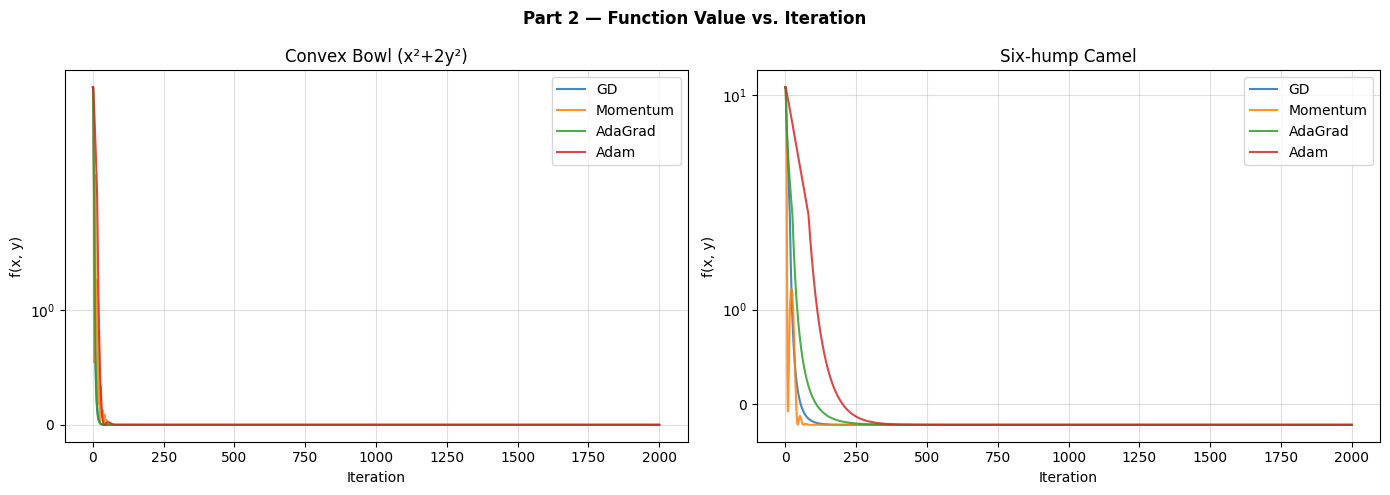

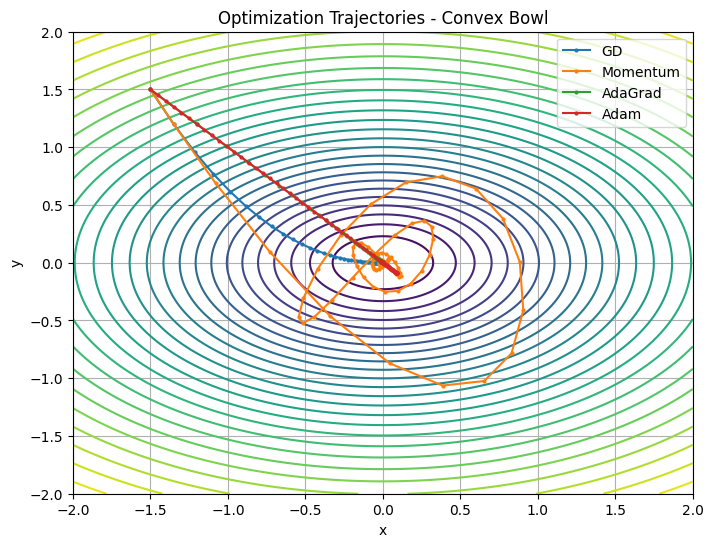

/tmp/ipykernel_2872/3344663934.py:25: RuntimeWarning: invalid value encountered in log1p
  plt.contour(X, Y, np.log1p(Z), levels=30)


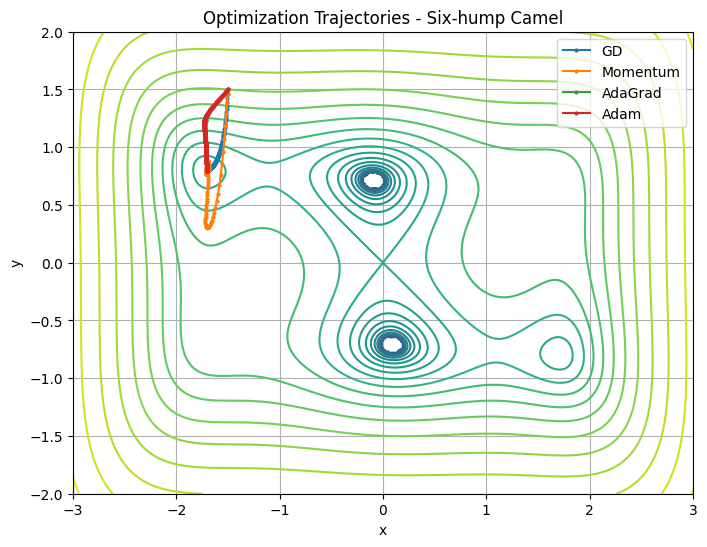

In [ ]:
# Plot 1: Function value vs. iteration
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, results, title in zip(axes,
        [results_bowl, results_camel],
        ["Convex Bowl (x²+2y²)", "Six-hump Camel"]):
    for name, (_, vals) in results.items():
        ax.plot(vals, label=name, alpha=0.85)
    ax.set_xlabel("Iteration")
    ax.set_ylabel("f(x, y)")
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.set_yscale('symlog')

plt.suptitle("Part 2 — Function Value vs. Iteration", fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Nebius_Course/part2_convergence.png', dpi=120)
plt.show()

# Vectorized wrappers for grid evaluation (original bowl/camel unchanged)
def bowl_grid(theta):
    x, y = theta[..., 0], theta[..., 1]
    return x**2 + 2*y**2

def camel_grid(theta):
    x, y = theta[..., 0], theta[..., 1]
    return (4 - 2.1*x**2 + x**4/3)*x**2 + x*y + (-4 + 4*y**2)*y**2

# Plot 2: Trajectories — disable plt.show() temporarily to save before displaying
original_show = plt.show

for f_grid, results, title, fname, xlim, ylim in [
    (bowl_grid,  results_bowl,  "Optimization Trajectories - Convex Bowl",
     '/content/drive/MyDrive/Nebius_Course/part2_traj_bowl.png',  (-2,2), (-2,2)),
    (camel_grid, results_camel, "Optimization Trajectories - Six-hump Camel",
     '/content/drive/MyDrive/Nebius_Course/part2_traj_camel.png', (-3,3), (-2,2)),
]:
    plt.show = lambda: None
    plot_trajectories_camel_log(f_grid, results, xlim=xlim, ylim=ylim, title=title)
    plt.savefig(fname, dpi=120)
    plt.show = original_show
    plt.show()

**Convex Bowl - Function Value vs. Iteration**

All four optimizers converge to zero (the global minimum) reliably. GD and AdaGrad follow the smoothest, most direct paths. Momentum overshoots significantly, visible in the trajectory plot as a large spiral loop going all the way down to y=-1.0 before circling back, because it accumulates velocity and overshoots the minimum. Adam also overshoots but recovers faster. In terms of convergence speed on the bowl, GD and AdaGrad are actually the most well-behaved with these hyperparameters.

**Six-hump Camel - Function Value vs. Iteration**

GD, Momentum, and AdaGrad all converge quickly (around iteration 50-150), while Adam is noticeably the slowest (~iteration 900) despite using a higher learning rate (lr=0.005 vs lr=0.001 for GD and Momentum).This is partially explained by Adam's bias correction mechanism: in early iterations, the correction factor 1/(1 - beta2^t) inflates v_hat, making the denominator sqrt(v_hat) larger and the effective step size smaller, Adam starts conservatively. However, this bias correction effect fades after ~50-100 steps and cannot alone explain why Adam takes ~900 iterations. The slower convergence on the Camel is more likely due to Adam's per-parameter adaptive scaling interacting poorly with the Camel's complex curvature — the same adaptivity that makes Adam robust in general can cause it to over-adapt in specific landscapes, making it slower than simpler methods like GD and Momentum on this particular function. All four optimizers reach a final value of approximately -0.215, which from the multi-start experiment we know is a local minimum, not the global one (-1.0316). The trajectory plot confirms this — all optimizers get trapped in the local minimum near (-2, 0.8), never escaping to explore the rest of the landscape.

**Multi-start experiment**

I notice that only starting point (0.5, 0.5) finds the global minimum (-1.0316) for all optimizers, while both (-1.5, 1.5) and (2.0, -1.0) get trapped at -0.2155. This confirms that no first-order optimizer reliably finds the global optimum - the outcome depends on the starting point, not only on the optimizer choice.

**Do the same hyperparameters work for both functions?**

No. The bowl requires moderate learning rates and tolerates momentum well.The Camel's complex landscape with sharp ridges requires much smaller learning rates, the same lr that works smoothly on the bowl causes Momentum to overshoot dramatically as seen in the trajectory plot.

**Advantages of Momentum, AdaGrad, and Adam over plain GD**

Plain GD updates parameters using only the current gradient with a fixed step size, which can be slow on poorly scaled functions. Momentum improves on this by accumulating past gradients into a velocity term, allowing faster progress along consistent directions visible on the bowl where it initially moves much faster than GD. AdaGrad adapts the learning rate per parameter based on accumulated squared gradients, effectively taking larger steps for infrequent features and smaller steps for frequent ones, this explains its smooth, direct trajectory on the bowl. Adam combines both ideas: it uses momentum for the first moment and AdaGrad-like scaling for the second moment, with bias correction to prevent large steps early in training. In practice Adam is the most robust of the four, requiring less hyperparameter tuning to perform well across different function geometries.

### **Knowledge Bonus.** An attempt at explaining the L1 regularization phenomenon + a bit about proximal descent



The antigradient of the regularized loss $\mathcal{L}_{reg}(w) = \mathcal{L}(w) + \lambda\|w\|_1$ is
$$-\nabla_w\mathcal{L}_{reg}(w) = -\nabla_w\mathcal{L}(w) - \lambda\cdot \mathrm{sign}(w),$$
where $\mathrm{sgn}$ is the elementwise sign. This means that during the gradient descent the $i$-th coordinate of $w$ changes as
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) + \begin{cases}
-\alpha\lambda,\mbox{ if $w_i > 0$},\\
+\alpha\lambda,\mbox{ if $w_i < 0$},
\end{cases},$$
where $\alpha$ is the step size. In other words, the rightmost summand pushes our $w_i$ towards $0$ with force $\alpha\lambda$. Now, imagine that the $i$-th feature is not very important. In this case, most likely, $\frac{\partial}{\partial w_i}\mathcal{L}(w)$ is small (change in $w_i$ doesn't change the loss much). So, the dominant force is the $\pm\alpha\lambda$, which may explain the almost-linear trajectories.

Of course, since $\alpha\lambda$ is constant and doesn't depend on $w_i$. This prevents us from converging to zero and explains the final noisy behaviour of $w_i$. We just leap around the origin.

I'd like to add here that if we used proximal descent, the step would become a two-step procedure like this:

$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w),\\
w_i\mapsto\begin{cases}
w_i - \alpha\lambda,\mbox{ if $w_i \geqslant \alpha\lambda$},\\
0,\mbox{ if $|w_i| > \alpha\lambda$},\\
w_i + \alpha\lambda,\mbox{ if $w_i \leqslant -\alpha\lambda$},\\
\end{cases}$$
This way, small values of $w_i$ will be automatically zeroed, and they will only be able to escape zero again if the gradient push them hard enough.

**Comparison with L2 regularization**. For L2 regularization, the gradient step for the $i$-th coordinate would be
$$w_i \mapsto w_i - \alpha\frac{\partial}{\partial w_i}\mathcal{L}(w) - 2\alpha\lambda w_i$$
The rightmost term here depends on $w_i$; the closer it is to zero, the less influential it is, and the more important $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)$ becomes. However, if the $i$-th feature is so worthless that $\alpha\frac{\partial}{\partial w_i}\mathcal{L}(w)\approx 0$, the process
$$w_i \mapsto w_i -  2\alpha\lambda w_i$$
converges to zero in contrast with the leaping behaviour of
$$w_i\mapsto w_i \pm\alpha\lambda$$